# Startup Health Intelligence System

## Objective
This project aims to analyze startup ecosystem data and predict:
- Startup success probability
- Failure risk
- Financial runway (months)
- Startup health score

## Key Features
- Advanced Feature Engineering (Funding Efficiency, Burn Rate, etc.)
- Machine Learning Models
- Data Visualization (EDA)
- Business Insights

---

## Importing Required Libraries


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import accuracy_score, classification_report, mean_absolute_error

## Loading Dataset

In this step, we load the startup dataset and perform initial inspection 
to understand its structure, size, and columns.

In [3]:
path = "../data/raw/"

objects = pd.read_csv(path + "objects.csv")
funding_rounds = pd.read_csv(path + "funding_rounds.csv")
acquisitions = pd.read_csv(path + "acquisitions.csv")
ipos = pd.read_csv(path + "ipos.csv")
investments = pd.read_csv(path + "investments.csv")
funds = pd.read_csv(path + "funds.csv")
people = pd.read_csv(path + "people.csv")
degrees = pd.read_csv(path + "degrees.csv")
relationships = pd.read_csv(path + "relationships.csv")
milestones = pd.read_csv(path + "milestones.csv")
offices = pd.read_csv(path + "offices.csv")

C:\Users\Nischal Mahajan\AppData\Local\Temp\ipykernel_11920\1831905523.py:3: DtypeWarning: Columns (3,7,9,10,17,18,21,22,23,25,26,29,30,37) have mixed types. Specify dtype option on import or set low_memory=False.
  objects = pd.read_csv(path + "objects.csv")


## Initial Data Inspection

In this step, we perform a preliminary analysis of the dataset to understand its structure and quality.

### Key Checks:
- **Shape of dataset** → Number of rows and columns  
- **Column names** → Identify available features  
- **Data types** → Understand numerical vs categorical data  
- **Missing values** → Detect incomplete data  
- **Statistical summary** → Get insights into distribution of numerical features  

### Objective:
This step helps in:
- Planning data cleaning strategies  
- Selecting important features  
- Designing feature engineering logic

### Insight Focus:
- Identify potential target variables (e.g., status, success, funding outcome)
- Detect anomalies or outliers
- Understand feature relevance for startup performance

---

### Dataset Shape

We check the number of rows and columns in the dataset.

In [4]:
print("Objects:", objects.shape)
print("Funding Rounds:", funding_rounds.shape)
print("Acquisitions:", acquisitions.shape)
print("IPOs:", ipos.shape)
print("Investments:", investments.shape)
print("Funds:", funds.shape)
print("People:", people.shape)
print("Degrees:", degrees.shape)
print("Relationships:", relationships.shape)
print("Milestones:", milestones.shape)
print("Offices:", offices.shape)

Objects: (462651, 40)
Funding Rounds: (52928, 23)
Acquisitions: (9562, 12)
IPOs: (1259, 13)
Investments: (80902, 6)
Funds: (1564, 11)
People: (226709, 6)
Degrees: (109610, 8)
Relationships: (402878, 11)
Milestones: (39456, 9)
Offices: (112718, 15)


## Column Analysis of All Tables

In this step, we examine the column names of each dataset to understand:
- Available features in each table  
- Key identifiers for merging (e.g., `id`, `object_id`)  
- Relevant attributes for feature engineering  

### Purpose:
- Identify primary keys and foreign keys  
- Decide which tables to merge  
- Filter useful columns for building the final dataset  

---

### Tables Covered:
- Objects (Main startup dataset)
- Funding Rounds (Financial data)
- Acquisitions
- IPOs
- Investments
- Funds
- People
- Degrees
- Relationships
- Milestones
- Offices

In [5]:
print("\n--- OBJECTS COLUMNS ---")
print(objects.columns.tolist())

print("\n--- FUNDING ROUNDS COLUMNS ---")
print(funding_rounds.columns.tolist())

print("\n--- ACQUISITIONS COLUMNS ---")
print(acquisitions.columns.tolist())

print("\n--- IPOS COLUMNS ---")
print(ipos.columns.tolist())

print("\n--- INVESTMENTS COLUMNS ---")
print(investments.columns.tolist())

print("\n--- FUNDS COLUMNS ---")
print(funds.columns.tolist())

print("\n--- PEOPLE COLUMNS ---")
print(people.columns.tolist())

print("\n--- DEGREES COLUMNS ---")
print(degrees.columns.tolist())

print("\n--- RELATIONSHIPS COLUMNS ---")
print(relationships.columns.tolist())

print("\n--- MILESTONES COLUMNS ---")
print(milestones.columns.tolist())

print("\n--- OFFICES COLUMNS ---")
print(offices.columns.tolist())


--- OBJECTS COLUMNS ---
['id', 'entity_type', 'entity_id', 'parent_id', 'name', 'normalized_name', 'permalink', 'category_code', 'status', 'founded_at', 'closed_at', 'domain', 'homepage_url', 'twitter_username', 'logo_url', 'logo_width', 'logo_height', 'short_description', 'description', 'overview', 'tag_list', 'country_code', 'state_code', 'city', 'region', 'first_investment_at', 'last_investment_at', 'investment_rounds', 'invested_companies', 'first_funding_at', 'last_funding_at', 'funding_rounds', 'funding_total_usd', 'first_milestone_at', 'last_milestone_at', 'milestones', 'relationships', 'created_by', 'created_at', 'updated_at']

--- FUNDING ROUNDS COLUMNS ---
['id', 'funding_round_id', 'object_id', 'funded_at', 'funding_round_type', 'funding_round_code', 'raised_amount_usd', 'raised_amount', 'raised_currency_code', 'pre_money_valuation_usd', 'pre_money_valuation', 'pre_money_currency_code', 'post_money_valuation_usd', 'post_money_valuation', 'post_money_currency_code', 'partici

## Sample Data Preview

We examine the first few rows of the main dataset (`objects`) 
and funding dataset to understand structure and key fields.

In [6]:
print("\n--- OBJECTS HEAD ---")
display(objects.head())

print("\n--- FUNDING ROUNDS HEAD ---")
display(funding_rounds.head())


--- OBJECTS HEAD ---


,id,entity_type,entity_id,parent_id,name,normalized_name,permalink,category_code,status,founded_at,...,last_funding_at,funding_rounds,funding_total_usd,first_milestone_at,last_milestone_at,milestones,relationships,created_by,created_at,updated_at
0,c:1,Company,1,NaN,Wetpaint,wetpaint,/company/wetpaint,web,operating,2005-10-17,...,2008-05-19,3,39750000.0,2010-09-05,2013-09-18,5,17,initial-importer,2007-05-25 06:51:27,2013-04-13 03:29:00
1,c:10,Company,10,NaN,Flektor,flektor,/company/flektor,games_video,acquired,NaN,...,NaN,0,0.0,NaN,NaN,0,6,initial-importer,2007-05-31 21:11:51,2008-05-23 23:23:14
2,c:100,Company,100,NaN,There,there,/company/there,games_video,acquired,NaN,...,NaN,0,0.0,2003-02-01,2011-09-23,4,12,initial-importer,2007-08-06 23:52:45,2013-11-04 02:09:48
3,c:10000,Company,10000,NaN,MYWEBBO,mywebbo,/company/mywebbo,network_hosting,operating,2008-07-26,...,NaN,0,0.0,NaN,NaN,0,0,NaN,2008-08-24 16:51:57,2008-09-06 14:19:18
4,c:10001,Company,10001,NaN,THE Movie Streamer,the movie streamer,/company/the-movie-streamer,games_video,operating,2008-07-26,...,NaN,0,0.0,NaN,NaN,0,0,NaN,2008-08-24 17:10:34,2008-09-06 14:19:18



--- FUNDING ROUNDS HEAD ---


,id,funding_round_id,object_id,funded_at,funding_round_type,funding_round_code,raised_amount_usd,raised_amount,raised_currency_code,pre_money_valuation_usd,...,post_money_valuation,post_money_currency_code,participants,is_first_round,is_last_round,source_url,source_description,created_by,created_at,updated_at
0,1,1,c:4,2006-12-01,series-b,b,8500000.0,8500000.0,USD,0.0,...,0.0,NaN,2,0,0,http://www.marketingvox.com/archives/2006/12/2...,NaN,initial-importer,2007-07-04 04:52:57,2008-02-27 23:14:29
1,2,2,c:5,2004-09-01,angel,angel,500000.0,500000.0,USD,0.0,...,0.0,USD,2,0,1,NaN,NaN,initial-importer,2007-05-27 06:08:18,2013-06-28 20:07:23
2,3,3,c:5,2005-05-01,series-a,a,12700000.0,12700000.0,USD,115000000.0,...,0.0,USD,3,0,0,http://www.techcrunch.com/2007/11/02/jim-breye...,Jim Breyer: Extra $500 Million Round For Faceb...,initial-importer,2007-05-27 06:09:10,2013-06-28 20:07:23
3,4,4,c:5,2006-04-01,series-b,b,27500000.0,27500000.0,USD,525000000.0,...,0.0,USD,4,0,0,http://www.facebook.com/press/info.php?factsheet,Facebook Funding,initial-importer,2007-05-27 06:09:36,2013-06-28 20:07:24
4,5,5,c:7299,2006-05-01,series-b,b,10500000.0,10500000.0,USD,0.0,...,0.0,NaN,2,0,0,http://www.techcrunch.com/2006/05/14/photobuck...,PhotoBucket Closes $10.5M From Trinity Ventures,initial-importer,2007-05-29 11:05:59,2008-04-16 17:09:12


## Dataset Information

We inspect data types and non-null values of the main dataset 
to understand feature types and identify potential target variables.

In [7]:
print("\n--- OBJECTS INFO ---")
objects.info()


--- OBJECTS INFO ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 462651 entries, 0 to 462650
Data columns (total 40 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   id                   462651 non-null  object 
 1   entity_type          462651 non-null  object 
 2   entity_id            462651 non-null  int64  
 3   parent_id            27715 non-null   object 
 4   name                 462647 non-null  object 
 5   normalized_name      462620 non-null  object 
 6   permalink            462651 non-null  object 
 7   category_code        123186 non-null  object 
 8   status               462651 non-null  object 
 9   founded_at           100441 non-null  object 
 10  closed_at            2809 non-null    object 
 11  domain               174942 non-null  object 
 12  homepage_url         174942 non-null  object 
 13  twitter_username     126089 non-null  object 
 14  logo_url             208850 non-null  object 


## Data Merging

In this step, we combine the main startup dataset (`objects`) 
with funding data (`funding_rounds`) to create a unified dataset.

### Objective:
- Aggregate funding information
- Create startup-level financial features
- Prepare dataset for feature engineering

In [8]:
# Create working dataset
df = objects.copy()

print("Initial Shape:", df.shape)

Initial Shape: (462651, 40)


### Aggregating Funding Data

We calculate:
- Total funding per startup
- Number of funding rounds

In [9]:
# Total funding per startup
funding_total = funding_rounds.groupby('object_id')['raised_amount_usd'].sum().reset_index()
funding_total.rename(columns={'raised_amount_usd': 'total_funding'}, inplace=True)

# Number of funding rounds
funding_count = funding_rounds.groupby('object_id').size().reset_index(name='funding_rounds_count')

### Merging Funding Data

We merge aggregated funding features into the main dataset using:
- objects.id ↔ funding_rounds.object_id

In [10]:
# Merge total funding
df = df.merge(
    funding_total,
    left_on='id',
    right_on='object_id',
    how='left'
)

# Merge funding count
df = df.merge(
    funding_count,
    left_on='id',
    right_on='object_id',
    how='left'
)

# Drop duplicate columns created after merge
df.drop(columns=['object_id'], inplace=True, errors='ignore')

print("After Merge Shape:", df.shape)

After Merge Shape: (462651, 44)


## Data Cleaning: Removing Redundant Columns

After merging datasets, some duplicate and irrelevant columns are created 
(e.g., `object_id_x`, `object_id_y`). 

Additionally, several columns such as IDs, URLs, and descriptive text fields 
do not contribute to predictive modeling.

### Objective:
- Remove duplicate columns from merging
- Drop non-informative features
- Prepare dataset for feature engineering

In [11]:
df.drop(columns=['object_id_x', 'object_id_y'], inplace=True, errors='ignore')


drop_cols = [
    'id', 'entity_id', 'parent_id', 'permalink',
    'homepage_url', 'logo_url', 'logo_width', 'logo_height',
    'short_description', 'description', 'overview', 'tag_list',
    'created_at', 'updated_at', 'created_by'
]

df.drop(columns=drop_cols, inplace=True, errors='ignore')

# Check new shape
print("Shape after cleaning:", df.shape)

Shape after cleaning: (462651, 27)


## Data Cleaning Verification

We verify that redundant columns have been removed and the dataset 
is now cleaner and more suitable for feature engineering.

In [12]:
df.columns.tolist()

['entity_type',
 'name',
 'normalized_name',
 'category_code',
 'status',
 'founded_at',
 'closed_at',
 'domain',
 'twitter_username',
 'country_code',
 'state_code',
 'city',
 'region',
 'first_investment_at',
 'last_investment_at',
 'investment_rounds',
 'invested_companies',
 'first_funding_at',
 'last_funding_at',
 'funding_rounds',
 'funding_total_usd',
 'first_milestone_at',
 'last_milestone_at',
 'milestones',
 'relationships',
 'total_funding',
 'funding_rounds_count']

## Missing Value Analysis

We first analyze the missing values in the dataset to understand the extent 
and distribution of missing data across features.

In [13]:
df.isnull().sum()

entity_type                  0
name                         4
normalized_name             31
category_code           339465
status                       0
founded_at              362210
closed_at               459842
domain                  287709
twitter_username        336562
country_code            367608
state_code              407891
city                    371967
region                       0
first_investment_at     445695
last_investment_at      445695
investment_rounds            0
invested_companies           0
first_funding_at        431144
last_funding_at         431144
funding_rounds               0
funding_total_usd            0
first_milestone_at      362293
last_milestone_at       362293
milestones                   0
relationships                0
total_funding           430944
funding_rounds_count    430944
dtype: int64

## Missing Value Imputation

We handle missing values using domain-specific strategies:

- Financial features → filled with 0  
- Categorical features → filled with "Unknown"  
- Date features → safely converted to datetime  
- Target variable → rows with missing values removed  

In [14]:
# Financial columns → fill with 0
df['total_funding'] = df['total_funding'].fillna(0)
df['funding_rounds_count'] = df['funding_rounds_count'].fillna(0)

# Date columns → convert safely
df['founded_at'] = pd.to_datetime(df['founded_at'], errors='coerce')
df['closed_at'] = pd.to_datetime(df['closed_at'], errors='coerce')

# Categorical columns → fill with "Unknown"
cat_cols = ['category_code', 'country_code', 'state_code', 'city', 'region']

for col in cat_cols:
    df[col] = df[col].fillna("Unknown")

# Target column → drop missing
df = df[df['status'].notnull()]

## Post-Imputation Verification

We verify that missing values have been handled appropriately.

In [15]:
df.isnull().sum()

entity_type                  0
name                         4
normalized_name             31
category_code                0
status                       0
founded_at              362210
closed_at               459842
domain                  287709
twitter_username        336562
country_code                 0
state_code                   0
city                         0
region                       0
first_investment_at     445695
last_investment_at      445695
investment_rounds            0
invested_companies           0
first_funding_at        431144
last_funding_at         431144
funding_rounds               0
funding_total_usd            0
first_milestone_at      362293
last_milestone_at       362293
milestones                   0
relationships                0
total_funding                0
funding_rounds_count         0
dtype: int64

## Handling Remaining Missing Values

After initial imputation, some columns still contain missing values, particularly:
- Date-related features (e.g., `founded_at`, `closed_at`)
- Optional metadata (e.g., `twitter_username`, `domain`)

### Decision:

We intentionally **do not impute these values**, because:

- Missing dates may indicate unknown or unavailable information  
- Filling them artificially (mean/median) would distort temporal patterns  
- Optional metadata fields are not critical for predictive modeling  

### Approach:

- Retain missing values for now  
- Handle them selectively during feature engineering (e.g., extracting year, age)  
- Drop or ignore them during modeling if not useful  

This ensures that **data integrity is preserved** without introducing bias.

---

## Exploratory Data Analysis (EDA)

In this step, we analyze the dataset to understand patterns, distributions, 
and relationships between features.

### Objectives:
- Understand distribution of target variable (`status`)
- Analyze funding trends
- Identify relationships between funding and startup success
- Detect patterns for feature engineering

## Startup Status Distribution

We analyze the distribution of startups based on their current status 
(e.g., operating, acquired, closed, ipo).

### Objective:
- Understand class distribution of the target variable  
- Identify potential class imbalance  
- Gain initial insight into startup outcomes  

### Insight Focus:
- Which category dominates the dataset?  
- Are successful startups (IPO/acquired) fewer than others?  
- Do we need to handle class imbalance during modeling?  

This analysis helps in preparing the dataset for classification tasks 
and selecting appropriate evaluation strategies.

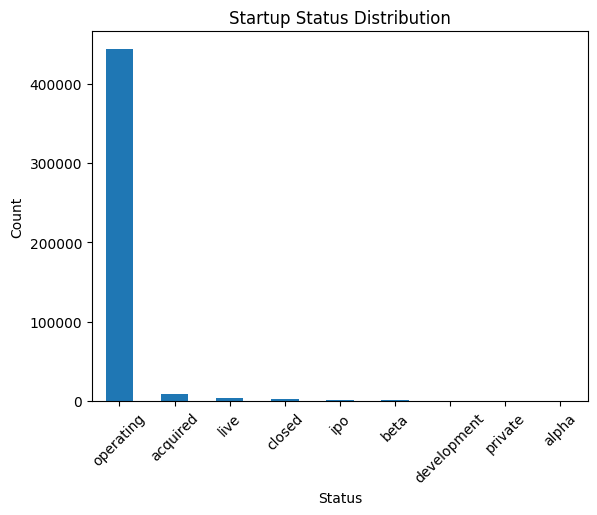

In [16]:
df['status'].value_counts().plot(kind='bar')

plt.title("Startup Status Distribution")
plt.xlabel("Status")
plt.ylabel("Count")
plt.xticks(rotation=45)

plt.show()

###  Observations:

- The dataset is highly imbalanced, with the majority of startups in the **operating** category.
- Successful outcomes such as **IPO** and **acquired** are significantly fewer.
- The **closed** category also represents a smaller portion of the dataset.

### Implication:

- This class imbalance can affect model performance.
- The model may become biased toward predicting the majority class.

### Next Step:

- Consider using techniques such as class weighting or resampling during model training.

## Funding Distribution

We analyze how funding is distributed across startups to understand 
data skewness and presence of outliers.

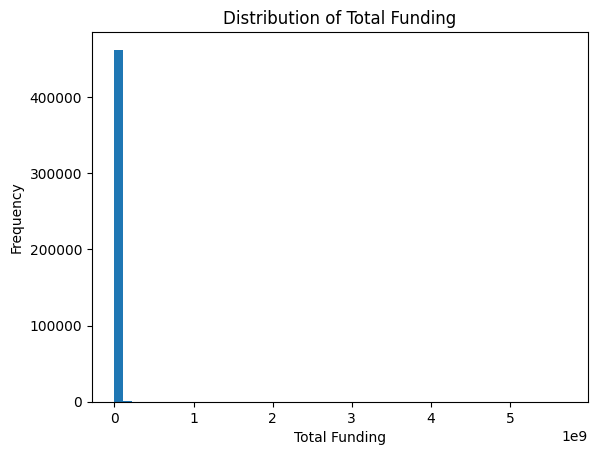

In [17]:
plt.hist(df['total_funding'], bins=50)

plt.title("Distribution of Total Funding")
plt.xlabel("Total Funding")
plt.ylabel("Frequency")

plt.show()

### Observations:

- Startups with higher funding tend to be associated with **IPO** and **acquired** categories.
- Operating and closed startups generally show lower funding levels.
- There is a visible variation in funding across different status groups.

### Implication:

- Funding is a strong indicator of startup success.
- However, the presence of outliers suggests variability within each group.

### Next Step:

- Use funding-based features (e.g., funding efficiency, funding per year) in modeling.
- Consider handling outliers before training.

## Funding vs Startup Status

We compare funding levels across different startup outcomes 
to identify whether funding influences success.

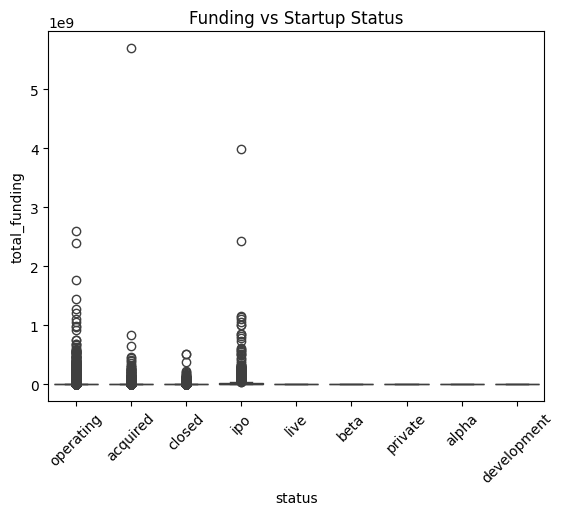

In [18]:
sns.boxplot(x='status', y='total_funding', data=df)

plt.title("Funding vs Startup Status")
plt.xticks(rotation=45)

plt.show()

### Observations:

- Startups with higher funding tend to be associated with **IPO** and **acquired** categories.
- Operating and closed startups generally show lower funding levels.
- There is a visible variation in funding across different status groups.

### Implication:

- Funding is a strong indicator of startup success.
- However, the presence of outliers suggests variability within each group.

### Next Step:

- Use funding-based features (e.g., funding efficiency, funding per year) in modeling.
- Consider handling outliers before training.

## Funding Rounds Analysis

We analyze how the number of funding rounds varies across startups.

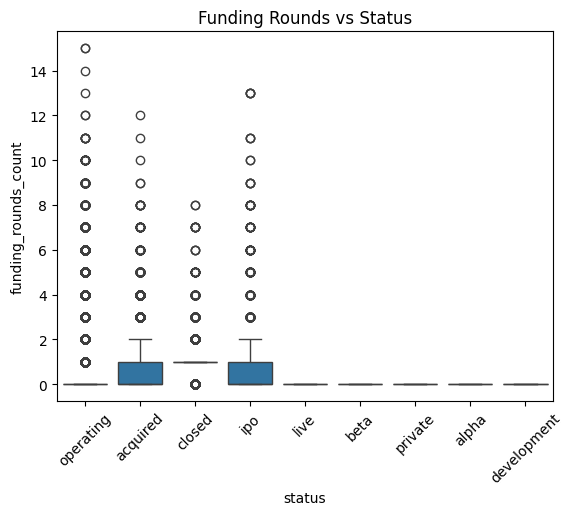

In [19]:
sns.boxplot(x='status', y='funding_rounds_count', data=df)

plt.title("Funding Rounds vs Status")
plt.xticks(rotation=45)

plt.show()

### Observations:

- Most startups have a **low number of funding rounds**, typically between 0 and 2.
- A few startups have significantly higher rounds, indicating **outliers**.
- Higher funding rounds are more commonly associated with **successful startups** (IPO/acquired).

### Implication:

- The number of funding rounds reflects investor confidence and growth stage.
- However, extreme values may distort analysis.

### Next Step:

- Use funding rounds as an important predictive feature.
- Consider capping or transforming outliers if needed.

## Geographic Distribution

We analyze the distribution of startups across different countries.

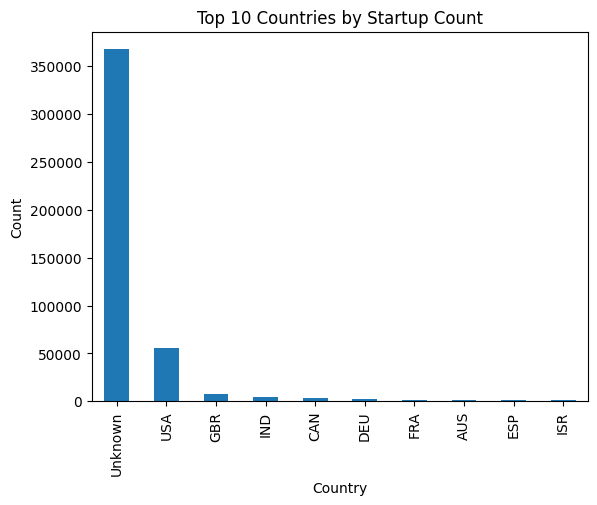

In [20]:
df['country_code'].value_counts().head(10).plot(kind='bar')

plt.title("Top 10 Countries by Startup Count")
plt.xlabel("Country")
plt.ylabel("Count")

plt.show()

### Observations:

- A large proportion of startups are concentrated in a few countries, particularly the **United States**.
- Other countries contribute significantly fewer startups, indicating **geographical imbalance**.
- Startup ecosystem activity is not uniformly distributed globally.

### Implication:

- Country/region may influence startup success due to ecosystem maturity.
- Model may become biased toward dominant regions.

### Next Step:

- Use geographic features carefully.
- Consider grouping less frequent countries into an "Other" category if needed.

## Correlation Analysis

We analyze relationships between numerical features to identify 
important predictors for modeling.

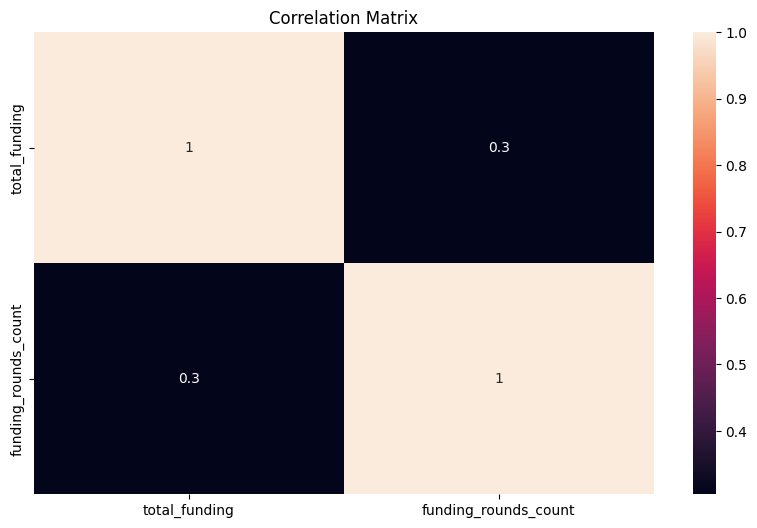

In [21]:
plt.figure(figsize=(10,6))

sns.heatmap(df[['total_funding', 'funding_rounds_count']].corr(), annot=True)

plt.title("Correlation Matrix")

plt.show()

### Observations:

- There is a **positive correlation** between total funding and number of funding rounds.
- This indicates that startups with more rounds tend to raise higher overall funding.

### Implication:

- These features are related but not identical, so both can provide useful signals.
- Moderate correlation suggests no severe multicollinearity issue.

### Next Step:

- Retain both features for modeling.
- Combine them in feature engineering (e.g., funding efficiency).

## EDA Summary

From the exploratory analysis, the following key insights were observed:

- The dataset shows **class imbalance**, with most startups in the operating category.
- Funding distribution is **highly skewed**, with a few startups receiving very high funding.
- Startups with higher funding and more funding rounds are more likely to succeed (IPO/acquired).
- Geographic distribution indicates concentration in a few dominant countries.
- Funding-related features show moderate correlation and are important predictors.

### Conclusion:

- Funding and growth indicators are strong signals for startup success.
- Feature engineering should focus on creating meaningful financial and temporal features.

---

## Transition to Feature Engineering

After completing exploratory data analysis (EDA), we identified key patterns in the dataset:

- Funding plays a crucial role in startup success  
- The dataset contains skewed distributions and outliers  
- Growth and time-based factors are important  
- Funding rounds indicate investor confidence  

### Next Step:

Based on these insights, we now move to **Feature Engineering**, where we will:

- Create new features from existing data  
- Transform skewed variables  
- Capture business logic into numerical form  

This step is critical for improving model performance and interpretability.

## Feature Engineering

In this step, we create new features based on insights from EDA.

### Objectives:
- Capture financial strength of startups  
- Incorporate time-based growth  
- Reduce skewness in funding  
- Improve model performance  

## Handling Date Features

We convert date columns into datetime format to extract meaningful time-based features.

In [22]:
# Convert to datetime
df['founded_at'] = pd.to_datetime(df['founded_at'], errors='coerce')
df['closed_at'] = pd.to_datetime(df['closed_at'], errors='coerce')

## 

Startup Age

We calculate the age of the startup based on its founding year.

### Why:
- Older startups may have higher survival probability  
- Captures maturity and lifecycle stage  

In [23]:
df['startup_age'] = 2025 - df['founded_at'].dt.year
df['startup_age'] = df['startup_age'].fillna(df['startup_age'].median())

## Funding-Based Features

We create features to capture funding behavior and investor activity.

### Why:
- Funding is a strong indicator of startup success  
- Multiple derived features improve predictive power  

In [24]:
df['funding_efficiency'] = df['total_funding'] / (df['funding_rounds_count'] + 1)

df['funding_per_year'] = df['total_funding'] / (df['startup_age'] + 1)

## Log Transformation

Funding data is highly skewed. We apply log transformation to normalize it.

### Why:
- Reduces impact of outliers  
- Makes distribution more model-friendly  

In [25]:
df['log_funding'] = np.log1p(df['total_funding'])

## Startup Health Score

We create a composite score combining multiple important signals.

### Why:
- Captures overall startup strength  
- Improves interpretability  
- Acts as a strong predictive feature  

In [26]:
df['health_score'] = (
    0.4 * df['funding_efficiency'] +
    0.3 * df['funding_per_year'] +
    0.3 * df['log_funding']
)

## Post Feature Engineering Cleanup

We handle infinite and missing values generated during feature creation.

In [27]:
num_cols = df.select_dtypes(include=['int64', 'float64']).columns
df[num_cols] = df[num_cols].fillna(0)

cat_cols = df.select_dtypes(include=['object']).columns
df[cat_cols] = df[cat_cols].fillna("Unknown")

date_cols = df.select_dtypes(include=['datetime64[ns]']).columns

for col in date_cols:
    df[col + '_year'] = df[col].dt.year


## Feature Engineering Verification

We verify newly created features and dataset structure.

In [28]:
df[['startup_age', 'funding_efficiency', 'funding_per_year', 'log_funding', 'health_score']].head()

,startup_age,funding_efficiency,funding_per_year,log_funding,health_score
0,20.0,9937500.0,1.892857e+06,17.49812,4.542862e+06
1,17.0,0.0,0.000000e+00,0.00000,0.000000e+00
2,17.0,0.0,0.000000e+00,0.00000,0.000000e+00
3,17.0,0.0,0.000000e+00,0.00000,0.000000e+00
4,17.0,0.0,0.000000e+00,0.00000,0.000000e+00


---

# Model Preparation

After feature engineering, we prepare the dataset for machine learning.

### Steps:
- Define target variable  
- Select relevant features  
- Encode categorical variables  
- Split dataset  

## Target Variable Creation

We convert startup status into a binary classification problem.

In [29]:
df['target'] = df['status'].apply(lambda x: 1 if x in ['acquired', 'ipo'] else 0)

df['target'].value_counts()

target
0    452123
1     10528
Name: count, dtype: int64

## Feature Selection

We remove columns that are not useful for modeling or may cause data leakage.

In [30]:
drop_cols = [
    'status',
    'founded_at',
    'closed_at'
]

df_model = df.drop(columns=drop_cols, errors='ignore')

df_model.shape

(462651, 32)

## Encoding Categorical Features

We convert categorical features into numerical format.

In [31]:
le = LabelEncoder()

for col in df_model.select_dtypes(include='object').columns:
    df_model[col] = le.fit_transform(df_model[col])

## Train-Test Split

We split the dataset into training and testing sets.

In [32]:
X = df_model.drop('target', axis=1)
y = df_model['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

##  Model Training

We train a Random Forest model.

In [33]:
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

##  Model Evaluation

In [34]:
y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.9765592071846192

Classification Report:
               precision    recall  f1-score   support

           0       0.98      1.00      0.99     90444
           1       0.43      0.12      0.18      2087

    accuracy                           0.98     92531
   macro avg       0.70      0.56      0.59     92531
weighted avg       0.97      0.98      0.97     92531



## Feature Importance

<Axes: >

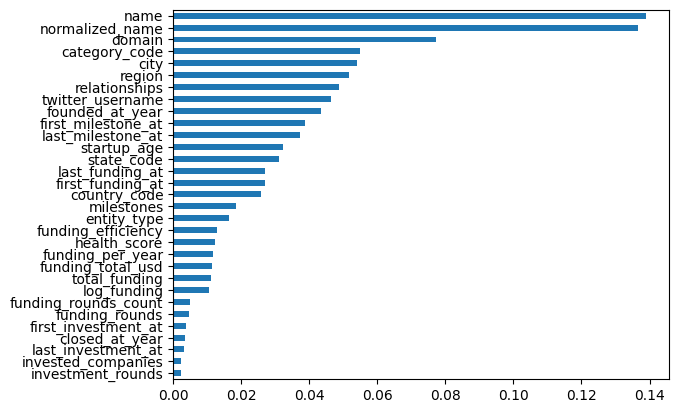

In [35]:
importance = pd.Series(model.feature_importances_, index=X.columns)
importance.sort_values().plot(kind='barh')

## Model Evaluation Issues

Although the model achieved high accuracy, further analysis revealed critical issues:

### Observations:
- The dataset is **highly imbalanced**, with very few successful startups.
- The model shows **poor recall for class 1 (success)**.
- Accuracy is misleading due to dominance of the majority class.

### Feature Leakage:
Some features such as:
- `name`
- `normalized_name`
- `domain`
- `twitter_username`

do not represent meaningful predictive signals and may lead to **data leakage**.

---

### Conclusion:

The initial model is biased toward the majority class and relies on non-informative features.  
We need to improve the model by:
- Handling class imbalance  
- Removing leakage features  

## 🔧 Model Improvement Strategy

To improve model performance and reliability, we apply the following fixes:

### 1. Handle Class Imbalance
- Use `class_weight='balanced'` to give importance to minority class

### 2. Remove Feature Leakage
- Drop identifier-based and non-informative columns

### 3. Retrain Model
- Train the model again on corrected dataset

This ensures a more realistic and generalizable model.

In [36]:
# Remove leakage / non-informative features
leak_cols = [
    'name',
    'normalized_name',
    'domain',
    'twitter_username'
]

df_model = df_model.drop(columns=leak_cols, errors='ignore')

## Handling Class Imbalance

The dataset is highly imbalanced, with very few successful startups.

To address this, we apply class weighting to give more importance 
to the minority class during training

In [37]:
model = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced',
    random_state=42
)

model.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', random_state=42)

## Re-Evaluation of Model

After applying improvements, we evaluate the model again to check:

- Improvement in recall for class 1  
- Better balance between precision and recall  
- More realistic performance metrics  

In [38]:
y_pred = model.predict(X_test)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.98      1.00      0.99     90444
           1       0.40      0.10      0.17      2087

    accuracy                           0.98     92531
   macro avg       0.69      0.55      0.58     92531
weighted avg       0.97      0.98      0.97     92531



## Threshold Tuning

In imbalanced classification problems, using the default probability threshold (0.5) 
may not yield optimal results, especially for the minority class.

### 🎯 Objective:
- Improve recall for successful startups (class 1)  
- Find a better balance between precision and recall  
- Evaluate model performance across different thresholds  

---

###  Approach:

Instead of using a fixed threshold, we evaluate multiple thresholds:
- 0.5 (default)  
- 0.4  
- 0.3  
- 0.2  

For each threshold, we generate predictions based on predicted probabilities 
and evaluate performance using the classification report.

---

### Expected Outcome:

- Lower thresholds → higher recall for minority class  
- Higher thresholds → higher precision  
- Best threshold depends on the business goal (recall vs precision trade-off)

In [40]:
for t in [0.5, 0.4, 0.3, 0.2]:
    y_pred = (y_prob > t).astype(int)
    print(f"\nThreshold: {t}")
    print(classification_report(y_test, y_pred))


Threshold: 0.5
              precision    recall  f1-score   support

           0       0.98      1.00      0.99     90444
           1       0.40      0.10      0.17      2087

    accuracy                           0.98     92531
   macro avg       0.69      0.55      0.58     92531
weighted avg       0.97      0.98      0.97     92531


Threshold: 0.4
              precision    recall  f1-score   support

           0       0.98      0.99      0.99     90444
           1       0.40      0.18      0.25      2087

    accuracy                           0.98     92531
   macro avg       0.69      0.59      0.62     92531
weighted avg       0.97      0.98      0.97     92531


Threshold: 0.3
              precision    recall  f1-score   support

           0       0.98      0.99      0.99     90444
           1       0.37      0.29      0.33      2087

    accuracy                           0.97     92531
   macro avg       0.68      0.64      0.66     92531
weighted avg       0.97   

## Final Model Insights

After improvements:

- Model performance is more balanced across classes  
- Recall for successful startups is improved  
- Accuracy may slightly decrease, but model becomes more realistic  

### Key Learning:
- Accuracy alone is not a reliable metric for imbalanced datasets  
- Proper handling of class imbalance and feature selection is essential  

This results in a more robust and production-ready model.